In [1]:
import pandas as pd
import numpy as np
import math
import datetime as dt
from matplotlib import pyplot as plt
import matplotlib.dates as mdates

import os
import shutil
import glob
import xarray as xr

from scipy.interpolate import griddata
from scipy.signal import argrelextrema, find_peaks

from bens_functions import *

import warnings
warnings.filterwarnings('ignore') 

In [2]:
# read in all of our data. 
usc_data = pd.read_csv('data/03_final/usc_data.csv')
usc_meta = pd.read_csv('data/03_final/usc_meta.csv')
uiuc_data = pd.read_csv('data/03_final/uiuc_data.csv')
uiuc_meta = pd.read_csv('data/03_final/uiuc_meta.csv')

In [3]:
usc_data['timestamp'] = pd.to_datetime(usc_data['timestamp'])
uiuc_data['timestamp'] = pd.to_datetime(uiuc_data['timestamp'])

In [4]:
usc_meta['start'] = pd.to_datetime(usc_meta['start']) + pd.Timedelta(hours=7) 
usc_meta['end'] = pd.to_datetime(usc_meta['end']) + pd.Timedelta(hours=7) 

In [5]:
pd.set_option('display.float_format', '{:.2f}'.format)
usc_data.describe()

,Unnamed: 0,timestamp,distance,dist_lidar,azimuth,true_azimuth,zenith,analog,x,y,z
count,1874000.00,1874000,1874000.00,1874000.00,1874000.00,1874000.00,1874000.00,1874000.00,1874000.00,1874000.00,1874000.00
mean,936999.50,2018-11-03 00:35:59.711418624,753.75,752.85,2.60,122.60,2.35,10.48,294335.02,393152.55,269.69
min,0.00,2018-11-02 18:13:08,7.50,7.47,-10.00,110.00,-0.30,0.00,293705.91,392408.83,230.95
25%,468499.75,2018-11-02 21:37:19,380.62,379.44,2.80,122.80,1.00,3.45,294020.68,392952.61,245.87
50%,936999.50,2018-11-03 00:48:27,753.75,752.19,3.00,123.00,2.25,4.72,294334.94,393153.59,260.79
75%,1405499.25,2018-11-03 03:27:35,1126.88,1125.71,3.20,123.20,3.67,6.32,294649.98,393354.78,286.41
max,1873999.00,2018-11-03 06:48:18,1500.00,1500.00,20.00,140.00,5.20,599.85,295110.64,393555.34,374.75
std,540977.35,NaN,433.01,432.49,1.88,1.88,1.54,25.49,364.49,234.09,29.29


In [6]:
usc_data_trimmed = usc_data[usc_data['distance']<=500]
usc_data_trimmed.describe()

,Unnamed: 0,timestamp,distance,dist_lidar,azimuth,true_azimuth,zenith,analog,x,y,z
count,618420.00,618420,618420.00,618420.00,618420.00,618420.00,618420.00,618420.00,618420.00,618420.00,618420.00
mean,936932.50,2018-11-03 00:35:59.711419136,251.25,250.95,2.60,122.60,2.35,23.31,293912.41,393422.78,249.10
min,0.00,2018-11-02 18:13:08,7.50,7.47,-10.00,110.00,-0.30,0.00,293705.91,393178.71,236.21
25%,468432.75,2018-11-02 21:37:19,127.50,127.40,2.80,122.80,1.00,5.71,293807.96,393356.85,241.20
50%,936932.50,2018-11-03 00:48:27,251.25,250.73,3.00,123.00,2.25,9.93,293914.05,393423.15,246.14
75%,1405432.25,2018-11-03 03:27:35,375.00,374.71,3.20,123.20,3.67,25.85,294015.59,393488.86,254.63
max,1873865.00,2018-11-03 06:48:18,495.00,495.00,20.00,140.00,5.20,599.85,294166.25,393555.34,283.66
std,540977.64,NaN,142.88,142.71,1.88,1.88,1.54,41.49,120.27,77.25,9.71


In [7]:
uiuc_data.describe()

,Unnamed: 0,timestamp,distance,dist_lidar,azimuth,true_azimuth,zenith,analog,x,y,z
count,5017500.00,5017500,5017500.00,5017500.00,5017500.00,5017500.00,5017500.00,5017500.00,5017500.00,5017500.00,5017500.00
mean,2508749.50,2018-11-03 00:27:58.551767296,939.38,931.96,68.87,364.87,5.26,26.47,294001.83,393979.11,320.17
min,0.00,2018-11-02 17:30:24,3.75,0.00,0.00,296.00,-0.00,0.00,292362.49,392960.33,235.60
25%,1254374.75,2018-11-02 21:08:30,471.56,464.52,24.00,320.00,2.40,9.81,293354.72,393639.64,257.40
50%,2508749.50,2018-11-03 00:34:55,939.38,932.09,112.00,408.00,5.00,10.16,293954.46,393977.34,296.85
75%,3763124.25,2018-11-03 03:47:52,1407.19,1399.30,112.00,408.00,7.60,11.58,294648.10,394315.47,362.14
max,5017499.00,2018-11-03 07:06:23,1875.00,1875.00,165.00,461.00,90.00,1000.00,295786.65,394775.25,2110.60
std,1448427.63,NaN,541.26,539.91,44.78,44.78,5.32,81.45,748.82,399.09,90.50


In [8]:
uiuc_data_trimmed = uiuc_data[uiuc_data['distance']<=300]
uiuc_data_trimmed.describe()

,Unnamed: 0,timestamp,distance,dist_lidar,azimuth,true_azimuth,zenith,analog,x,y,z
count,802800.00,802800,802800.00,802800.00,802800.00,802800.00,802800.00,802800.00,802800.00,802800.00,802800.00
mean,2508539.50,2018-11-03 00:27:58.551769344,151.88,150.68,68.87,364.87,5.26,106.30,293955.11,393424.97,249.27
min,0.00,2018-11-02 17:30:24,3.75,0.00,0.00,296.00,-0.00,0.00,293692.72,393260.86,235.60
25%,1254059.75,2018-11-02 21:08:30,77.81,74.97,24.00,320.00,2.40,10.59,293850.25,393370.54,239.17
50%,2508539.50,2018-11-03 00:34:55,151.88,149.98,112.00,408.00,5.00,43.51,293948.88,393424.60,245.52
75%,3763019.25,2018-11-03 03:47:52,225.94,224.99,112.00,408.00,7.60,126.59,294059.81,393478.68,256.00
max,5017079.00,2018-11-03 07:06:23,300.00,300.00,165.00,461.00,90.00,1000.00,294240.59,393551.24,535.60
std,1448428.38,NaN,86.60,86.39,44.78,44.78,5.32,182.00,120.75,63.89,14.56


In [9]:
import bens_functions as bf

In [10]:
usc_meta = usc_meta.sort_values(by='start')
usc_meta.head()

,Unnamed: 0,file,start,end,elevation,longitude,latitude,zenith,azimuth,temp_ground,pressure
8775,8775,./data/02_processed/USC/S18B0211.131016.txt,2018-11-02 18:13:08,2018-11-02 18:13:10,214.00,40.20,88.40,-0.00,-10.00,6.00,1013.00
6222,6222,./data/02_processed/USC/S18B0211.131630.txt,2018-11-02 18:13:14,2018-11-02 18:13:16,214.00,40.20,88.40,-0.00,-9.00,6.00,1013.00
7201,7201,./data/02_processed/USC/S18B0211.135117.txt,2018-11-02 18:13:49,2018-11-02 18:13:51,214.00,40.20,88.40,-0.00,-10.00,6.00,1013.00
1400,1400,./data/02_processed/USC/S18B0211.135746.txt,2018-11-02 18:13:55,2018-11-02 18:13:57,214.00,40.20,88.40,-0.00,-9.00,6.00,1013.00
1997,1997,./data/02_processed/USC/S18B0211.140376.txt,2018-11-02 18:14:02,2018-11-02 18:14:03,214.00,40.20,88.40,-0.00,-8.00,6.00,1013.00


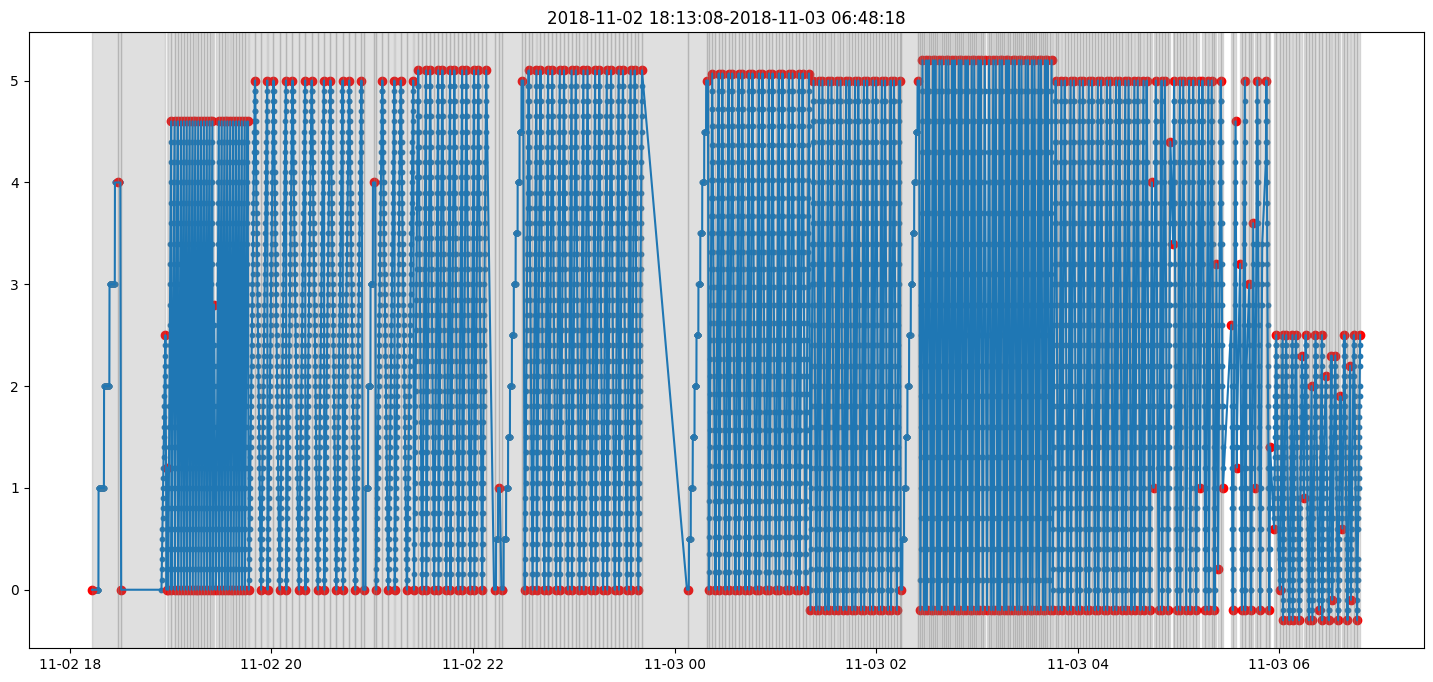

In [11]:
usc_scans = bf.find_scans(usc_meta)

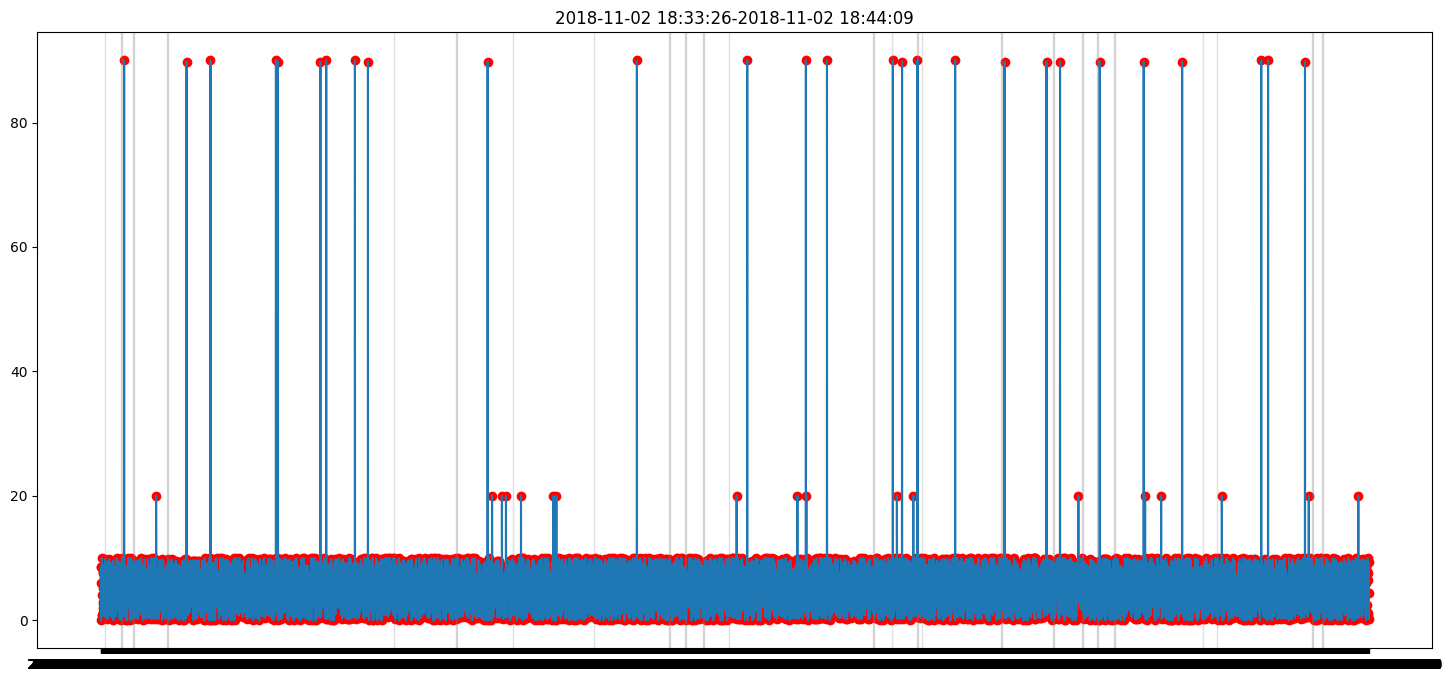

In [12]:
uiuc_scans = bf.find_scans(uiuc_meta)

In [13]:
print(len(usc_scans))
print(len(uiuc_scans))

2
2


In [14]:
usc_data_trimmed

,Unnamed: 0,source,timestamp,distance,dist_lidar,azimuth,true_azimuth,zenith,analog,x,y,z
0,0,USC,2018-11-03 03:52:04,7.50,7.48,2.80,122.80,4.20,3.88,293707.39,393553.85,239.35
1,1,USC,2018-11-03 03:52:04,15.00,14.96,2.80,122.80,4.20,3.88,293713.67,393549.80,239.90
2,2,USC,2018-11-03 03:52:04,22.50,22.44,2.80,122.80,4.20,3.86,293719.96,393545.74,240.45
3,3,USC,2018-11-03 03:52:04,30.00,29.92,2.80,122.80,4.20,3.88,293726.25,393541.69,241.00
4,4,USC,2018-11-03 03:52:04,37.50,37.40,2.80,122.80,4.20,3.81,293732.54,393537.64,241.55
...,...,...,...,...,...,...,...,...,...,...,...,...
1873861,1873861,USC,2018-11-02 20:28:08,465.00,464.97,3.20,123.20,0.70,5.62,294090.17,393303.30,244.48
1873862,1873862,USC,2018-11-02 20:28:08,472.50,472.46,3.20,123.20,0.70,5.78,294096.44,393299.20,244.57
1873863,1873863,USC,2018-11-02 20:28:08,480.00,479.96,3.20,123.20,0.70,5.53,294102.72,393295.09,244.66
1873864,1873864,USC,2018-11-02 20:28:08,487.50,487.46,3.20,123.20,0.70,5.56,294108.99,393290.98,244.76


I need to create a background average and subtract that. I will test using the 1st quartile by distance as my background noise value. It needs to be greater than 0. 


Five-number summary grouped by Category:
           count  mean  std  min  25%  50%  75%    max
distance                                              
7.50     9370.00  3.76 0.70 3.05 3.23 3.30 4.70   5.67
15.00    9370.00  3.76 0.70 3.03 3.23 3.30 4.70   5.68
22.50    9370.00  3.76 0.70 3.05 3.23 3.30 4.70   5.67
30.00    9370.00  3.76 0.70 3.07 3.23 3.30 4.70   5.67
37.50    9370.00  3.75 0.70 3.05 3.23 3.30 4.70   5.67
...          ...   ...  ...  ...  ...  ...  ...    ...
465.00   9370.00  6.15 1.98 3.15 5.10 6.32 7.08  99.98
472.50   9370.00  6.07 2.53 3.15 5.02 6.18 6.91  99.98
480.00   9370.00  5.97 2.43 3.12 4.96 6.05 6.75 102.47
487.50   9370.00  5.87 2.24 2.01 4.88 5.94 6.67 102.47
495.00   9370.00  5.77 2.20 0.90 4.83 5.81 6.56 102.47

[66 rows x 8 columns]


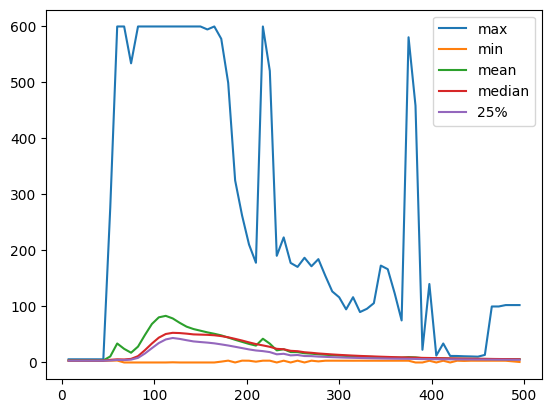

In [15]:
# group by distance and create a summary of values. 
usc_five_num_summary = usc_data_trimmed.groupby('distance')['analog'].describe()
print("\nFive-number summary grouped by Category:")
print(usc_five_num_summary)

plt.plot(usc_five_num_summary['max'], label='max')
plt.plot(usc_five_num_summary['min'], label='min')
plt.plot(usc_five_num_summary['mean'], label='mean')
plt.plot(usc_five_num_summary['50%'], label='median')
plt.plot(usc_five_num_summary['25%'], label='25%')
plt.legend()
plt.show()


Five-number summary grouped by Category:
            count  mean   std  min   25%   50%   75%     max
distance                                                    
3.75     10035.00  9.76  0.26 9.16  9.58  9.73  9.95   10.42
7.50     10035.00  9.76  0.27 9.15  9.58  9.73  9.95   10.44
11.25    10035.00  9.76  0.26 9.18  9.58  9.73  9.95   10.43
15.00    10035.00  9.76  0.26 9.18  9.58  9.73  9.95   10.43
18.75    10035.00  9.77  0.26 9.18  9.59  9.74  9.96   10.45
...           ...   ...   ...  ...   ...   ...   ...     ...
285.00   10035.00 37.08 95.96 0.00 10.40 29.39 31.94 1000.00
288.75   10035.00 36.29 97.62 0.04 10.20 28.53 31.07 1000.00
292.50   10035.00 30.44 64.42 0.00 10.07 27.80 30.25 1000.00
296.25   10035.00 26.01 45.31 0.00 10.04 26.98 29.42 1000.00
300.00   10035.00 26.93 45.31 0.00  9.94 26.38 28.75 1000.00

[80 rows x 8 columns]


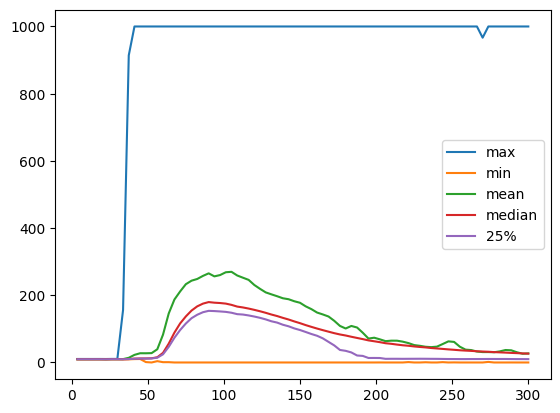

In [16]:
# group by distance and create a summary of values. 
uiuc_five_num_summary = uiuc_data_trimmed.groupby('distance')['analog'].describe()
print("\nFive-number summary grouped by Category:")
print(uiuc_five_num_summary)

plt.plot(uiuc_five_num_summary['max'], label='max')
plt.plot(uiuc_five_num_summary['min'], label='min')
plt.plot(uiuc_five_num_summary['mean'], label='mean')
plt.plot(uiuc_five_num_summary['50%'], label='median')
plt.plot(uiuc_five_num_summary['25%'], label='25%')
plt.legend()
plt.show()

In [17]:
# Need help here removing background. So, taking the background value at a specific distance (25%) 
# Subtract value at distance from each point at distances. 
# Q1 (25th percentile) of analog at each distance bin
q1_by_dist = usc_data_trimmed.groupby('distance')['analog'].quantile(0.25)

# attach the Q1 value for each row based on its distance
usc_data_trimmed['analog_q1_bg'] = usc_data_trimmed['distance'].map(q1_by_dist)

# background-corrected analog: if < Q1 -> 0, else subtract Q1
usc_data_trimmed['analog_bgc_q1'] = (usc_data_trimmed['analog'] - usc_data_trimmed['analog_q1_bg']).clip(lower=0)
usc_data_trimmed['analog_rcs'] = usc_data_trimmed['analog_bgc_q1'] * (usc_data_trimmed['distance'] ** 2)

peak = usc_data_trimmed['analog_rcs'].max()
usc_data_trimmed['analog_rcs_norm'] = usc_data_trimmed['analog_rcs'] / peak if peak != 0 else 0

usc_data_trimmed

,Unnamed: 0,source,timestamp,distance,dist_lidar,azimuth,true_azimuth,zenith,analog,x,y,z,analog_q1_bg,analog_bgc_q1,analog_rcs,analog_rcs_norm
0,0,USC,2018-11-03 03:52:04,7.50,7.48,2.80,122.80,4.20,3.88,293707.39,393553.85,239.35,3.23,0.65,36.39,0.00
1,1,USC,2018-11-03 03:52:04,15.00,14.96,2.80,122.80,4.20,3.88,293713.67,393549.80,239.90,3.23,0.65,145.55,0.00
2,2,USC,2018-11-03 03:52:04,22.50,22.44,2.80,122.80,4.20,3.86,293719.96,393545.74,240.45,3.23,0.62,315.14,0.00
3,3,USC,2018-11-03 03:52:04,30.00,29.92,2.80,122.80,4.20,3.88,293726.25,393541.69,241.00,3.23,0.65,582.21,0.00
4,4,USC,2018-11-03 03:52:04,37.50,37.40,2.80,122.80,4.20,3.81,293732.54,393537.64,241.55,3.23,0.57,806.77,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1873861,1873861,USC,2018-11-02 20:28:08,465.00,464.97,3.20,123.20,0.70,5.62,294090.17,393303.30,244.48,5.10,0.51,111355.87,0.00
1873862,1873862,USC,2018-11-02 20:28:08,472.50,472.46,3.20,123.20,0.70,5.78,294096.44,393299.20,244.57,5.02,0.76,169607.77,0.00
1873863,1873863,USC,2018-11-02 20:28:08,480.00,479.96,3.20,123.20,0.70,5.53,294102.72,393295.09,244.66,4.96,0.57,131927.04,0.00
1873864,1873864,USC,2018-11-02 20:28:08,487.50,487.46,3.20,123.20,0.70,5.56,294108.99,393290.98,244.76,4.88,0.68,160869.52,0.00


In [18]:
# Q1 (25th percentile) of analog at each distance bin
q1_by_dist = uiuc_data_trimmed.groupby('distance')['analog'].quantile(0.25)

# attach the Q1 value for each row based on its distance
uiuc_data_trimmed['analog_q1_bg'] = uiuc_data_trimmed['distance'].map(q1_by_dist)

# background-corrected analog: if < Q1 -> 0, else subtract Q1
uiuc_data_trimmed['analog_bgc_q1'] = (uiuc_data_trimmed['analog'] - uiuc_data_trimmed['analog_q1_bg']).clip(lower=0)
uiuc_data_trimmed['analog_rcs'] = uiuc_data_trimmed['analog_bgc_q1'] * (uiuc_data_trimmed['distance'] ** 2)

peak = uiuc_data_trimmed['analog_rcs'].max()
uiuc_data_trimmed['analog_rcs_norm'] = uiuc_data_trimmed['analog_rcs'] / peak if peak != 0 else 0

uiuc_data_trimmed

,Unnamed: 0,source,timestamp,distance,dist_lidar,azimuth,true_azimuth,zenith,analog,x,y,z,analog_q1_bg,analog_bgc_q1,analog_rcs,analog_rcs_norm
0,0,UIUC,2018-11-02 18:33:26,3.75,3.73,112.00,408.00,6.00,9.98,293948.87,393320.60,235.99,9.58,0.39,5.52,0.00
1,1,UIUC,2018-11-02 18:33:26,7.50,7.46,112.00,408.00,6.00,9.96,293951.64,393323.09,236.38,9.58,0.38,21.09,0.00
2,2,UIUC,2018-11-02 18:33:26,11.25,11.19,112.00,408.00,6.00,9.94,293954.41,393325.59,236.78,9.58,0.36,45.25,0.00
3,3,UIUC,2018-11-02 18:33:26,15.00,14.92,112.00,408.00,6.00,10.05,293957.19,393328.08,237.17,9.58,0.46,104.00,0.00
4,4,UIUC,2018-11-02 18:33:26,18.75,18.65,112.00,408.00,6.00,9.97,293959.96,393330.58,237.56,9.59,0.38,133.49,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5017075,5017075,UIUC,2018-11-02 18:44:09,285.00,284.16,25.00,321.00,4.40,30.70,293767.27,393538.93,257.46,10.40,20.31,1649525.42,0.02
5017076,5017076,UIUC,2018-11-02 18:44:09,288.75,287.90,25.00,321.00,4.40,31.17,293764.92,393541.84,257.75,10.20,20.97,1748631.63,0.02
5017077,5017077,UIUC,2018-11-02 18:44:09,292.50,291.64,25.00,321.00,4.40,30.12,293762.57,393544.75,258.04,10.07,20.04,1714949.36,0.02
5017078,5017078,UIUC,2018-11-02 18:44:09,296.25,295.38,25.00,321.00,4.40,28.83,293760.21,393547.65,258.33,10.04,18.79,1649218.38,0.02


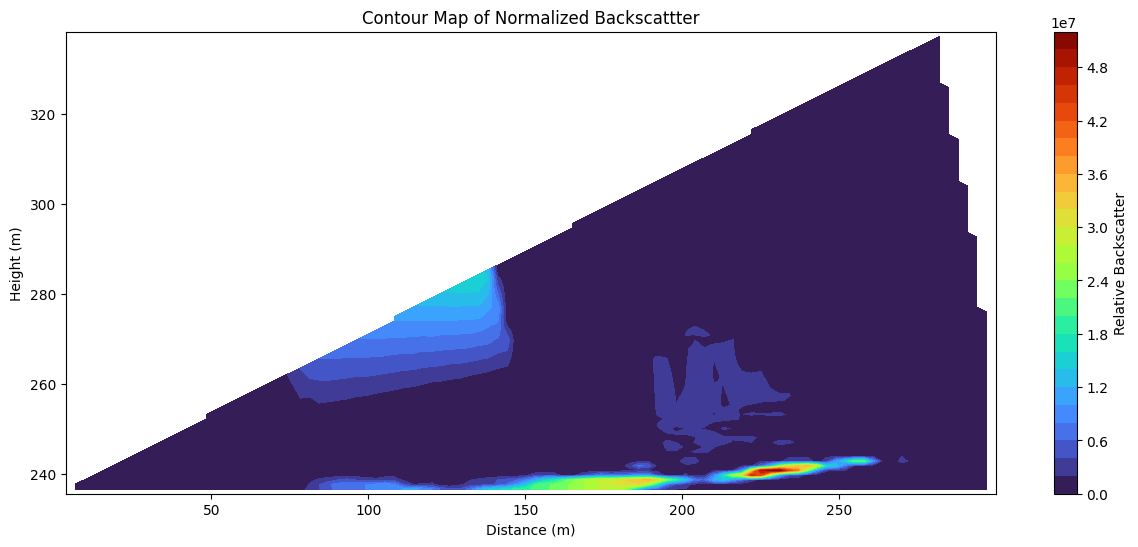

In [19]:
start = pd.to_datetime('2018-11-02 21:15:00')
stop = pd.to_datetime('2018-11-02 21:20:00')
temp = uiuc_data_trimmed[(uiuc_data_trimmed['timestamp']>start) & (uiuc_data_trimmed['timestamp']<=stop)]
plot_contour_scan(temp, dist_col='dist_lidar', column='analog_rcs', method='linear')

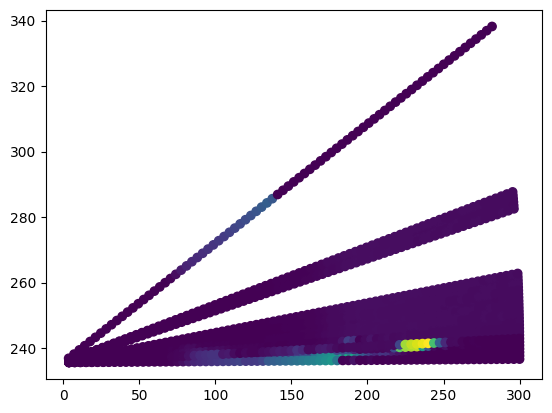

In [20]:
plt.scatter(temp['dist_lidar'], temp['z'], c=temp['analog_rcs'])

In [21]:
temp['true_azimuth'].unique()

array([320. , 320.7, 296. ])

In [22]:
#### Must fix relative distance to lidar. 

# must fix angles. Board, slope, etc. 

#

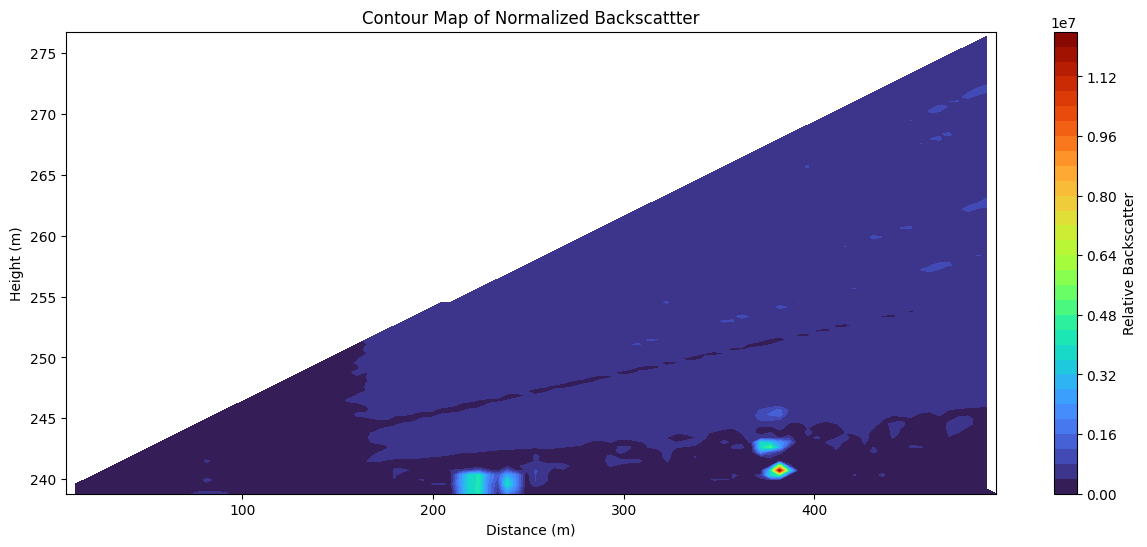

In [35]:
start = pd.to_datetime('2018-11-02 21:20:00')
stop = pd.to_datetime('2018-11-02 21:24:00')
temp = usc_data_trimmed[(usc_data_trimmed['timestamp']>start) & (usc_data_trimmed['timestamp']<=stop)]
plot_contour_scan(temp, dist_col='dist_lidar', column='analog_rcs', method='linear')
# plt.scatter(temp['dist_lidar'], temp['z'], c=temp['analog_rcs'])

In [29]:
usc_data_trimmed

,Unnamed: 0,source,timestamp,distance,dist_lidar,azimuth,true_azimuth,zenith,analog,x,y,z,analog_q1_bg,analog_bgc_q1,analog_rcs,analog_rcs_norm
0,0,USC,2018-11-03 03:52:04,7.50,7.48,2.80,122.80,4.20,3.88,293707.39,393553.85,239.35,3.23,0.65,36.39,0.00
1,1,USC,2018-11-03 03:52:04,15.00,14.96,2.80,122.80,4.20,3.88,293713.67,393549.80,239.90,3.23,0.65,145.55,0.00
2,2,USC,2018-11-03 03:52:04,22.50,22.44,2.80,122.80,4.20,3.86,293719.96,393545.74,240.45,3.23,0.62,315.14,0.00
3,3,USC,2018-11-03 03:52:04,30.00,29.92,2.80,122.80,4.20,3.88,293726.25,393541.69,241.00,3.23,0.65,582.21,0.00
4,4,USC,2018-11-03 03:52:04,37.50,37.40,2.80,122.80,4.20,3.81,293732.54,393537.64,241.55,3.23,0.57,806.77,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1873861,1873861,USC,2018-11-02 20:28:08,465.00,464.97,3.20,123.20,0.70,5.62,294090.17,393303.30,244.48,5.10,0.51,111355.87,0.00
1873862,1873862,USC,2018-11-02 20:28:08,472.50,472.46,3.20,123.20,0.70,5.78,294096.44,393299.20,244.57,5.02,0.76,169607.77,0.00
1873863,1873863,USC,2018-11-02 20:28:08,480.00,479.96,3.20,123.20,0.70,5.53,294102.72,393295.09,244.66,4.96,0.57,131927.04,0.00
1873864,1873864,USC,2018-11-02 20:28:08,487.50,487.46,3.20,123.20,0.70,5.56,294108.99,393290.98,244.76,4.88,0.68,160869.52,0.00


In [30]:
temp

,Unnamed: 0,source,timestamp,distance,dist_lidar,azimuth,true_azimuth,zenith,analog,x,y,z,analog_q1_bg,analog_bgc_q1,analog_rcs,analog_rcs_norm
216400,216400,USC,2018-11-02 21:19:30,7.50,7.50,3.00,123.00,1.50,4.70,293707.39,393553.82,239.00,3.23,1.46,82.39,0.00
216401,216401,USC,2018-11-02 21:19:30,15.00,14.99,3.00,123.00,1.50,4.70,293713.68,393549.73,239.19,3.23,1.47,330.12,0.00
216402,216402,USC,2018-11-02 21:19:30,22.50,22.49,3.00,123.00,1.50,4.69,293719.96,393545.65,239.39,3.23,1.46,739.07,0.00
216403,216403,USC,2018-11-02 21:19:30,30.00,29.99,3.00,123.00,1.50,4.69,293726.25,393541.57,239.59,3.23,1.46,1311.75,0.00
216404,216404,USC,2018-11-02 21:19:30,37.50,37.49,3.00,123.00,1.50,4.70,293732.54,393537.48,239.78,3.23,1.46,2059.88,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1708461,1708461,USC,2018-11-02 21:19:09,465.00,464.72,3.00,123.00,2.00,8.17,294090.84,393304.80,255.03,5.10,3.07,663032.34,0.01
1708462,1708462,USC,2018-11-02 21:19:09,472.50,472.21,3.00,123.00,2.00,7.82,294097.13,393300.71,255.29,5.02,2.80,625720.29,0.01
1708463,1708463,USC,2018-11-02 21:19:09,480.00,479.71,3.00,123.00,2.00,7.56,294103.42,393296.63,255.55,4.96,2.60,599616.00,0.01
1708464,1708464,USC,2018-11-02 21:19:09,487.50,487.20,3.00,123.00,2.00,7.73,294109.70,393292.55,255.81,4.88,2.85,677700.56,0.01


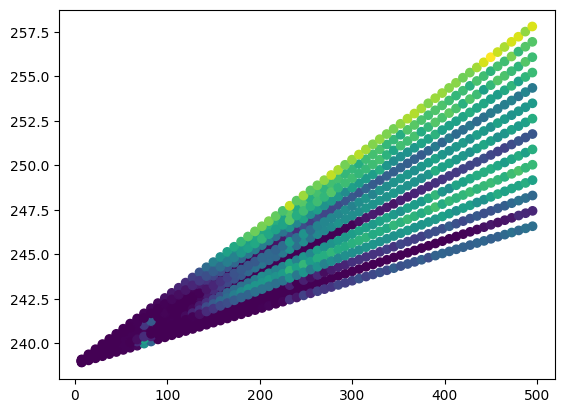

In [32]:
plt.scatter(temp['dist_lidar'], temp['z'] ,c = temp['analog_rcs'])